In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

import holidays

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam, Nadam
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
pip install keras-tuner

------
РАБОТАЕМ

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import holidays

# =========================
# 1. LOAD
# =========================
df = pd.read_excel("/content/drive/MyDrive/Diploma/RawData/all_clean+more_weather.xlsx", header=None)

df.columns = [
    'date', 'hour_range', 'forecast', 'actual',
    'temperature_2m', 'relative_humidity_2m', 'weather_code',
    'cloud_cover', 'wind_speed_10m', 'dew_point_2m',
    'apparent_temperature', 'surface_pressure', 'wind_speed_100m',
    'wind_direction_10m', 'soil_temperature_0_to_7cm',
    'soil_moisture_0_to_7cm'
]

df['is_date'] = df['date'].astype(str).str.match(r'\d{4}-\d{2}-\d{2}')
df['date'] = df['date'].where(df['is_date']).ffill()

df = df[pd.to_numeric(df['actual'], errors='coerce').notnull()].copy()

df['hour'] = df['hour_range'].str.split('--').str[0].astype(int)
df['datetime'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['hour'], unit='h')

df = df.sort_values('datetime').reset_index(drop=True)

# =========================
# 2. TIME FEATURES
# =========================
df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)

df['dow'] = df['datetime'].dt.dayofweek
df['dow_sin'] = np.sin(2*np.pi*df['dow']/7)
df['dow_cos'] = np.cos(2*np.pi*df['dow']/7)

df['month'] = df['datetime'].dt.month
df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)

# =========================
# 3. HOLIDAYS
# =========================
ru_holidays = holidays.Russia(years=df['datetime'].dt.year.unique())

df['is_weekend'] = df['dow'].isin([5,6]).astype(int)
df['is_holiday'] = df['datetime'].dt.date.apply(lambda x: int(x in ru_holidays))
df['is_special_day'] = ((df['is_weekend'] + df['is_holiday']) > 0).astype(int)

# =========================
# 4. LAGS + ROLLING (only past info)
# =========================
df['lag_1'] = df['actual'].shift(1)
df['lag_24'] = df['actual'].shift(24)
df['lag_168'] = df['actual'].shift(168)

df['roll_24'] = df['actual'].shift(1).rolling(24).mean()
df['roll_168'] = df['actual'].shift(1).rolling(168).mean()

# =========================
# 5. FEATURES
# =========================
weather_features = [
    'temperature_2m','relative_humidity_2m','cloud_cover',
    'wind_speed_10m','surface_pressure','apparent_temperature',
    'dew_point_2m','wind_speed_100m','soil_temperature_0_to_7cm',
    'weather_code','wind_direction_10m','soil_moisture_0_to_7cm'
]

features = [
    'hour_sin','hour_cos',
    'dow_sin','dow_cos',
    'month_sin','month_cos',
    'is_special_day',
    'lag_1','lag_24','lag_168',
    'roll_24','roll_168'
] + weather_features

target = 'actual'

# =========================
# 6. CLEAN
# =========================
df = df.dropna().reset_index(drop=True)

# =========================
# 7. TIME SPLIT (NO LEAKAGE)
# =========================
n = len(df)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df[:train_end].copy()
val_df = df[train_end:val_end].copy()
test_df = df[val_end:].copy()

# =========================
# 8. SCALING (FIT ONLY ON TRAIN)
# =========================
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_raw = scaler_X.fit_transform(train_df[features])
X_val_raw = scaler_X.transform(val_df[features])
X_test_raw = scaler_X.transform(test_df[features])

y_train_raw = scaler_y.fit_transform(train_df[[target]])
y_val_raw = scaler_y.transform(val_df[[target]])
y_test_raw = scaler_y.transform(test_df[[target]])

# =========================
# 9. SEQUENCE BUILDER
# =========================
LOOKBACK = 168   # 7 days
HORIZON = 24      # next day

def create_sequences(X, y, lookback=168, horizon=24):
    Xs, ys = [], []
    for i in range(len(X) - lookback - horizon):
        Xs.append(X[i:i+lookback])
        ys.append(y[i+lookback:i+lookback+horizon])
    return np.array(Xs), np.array(ys)

# =========================
# 10. BUILD SETS
# =========================
X_train, y_train = create_sequences(X_train_raw, y_train_raw, LOOKBACK, HORIZON)
X_val, y_val = create_sequences(X_val_raw, y_val_raw, LOOKBACK, HORIZON)
X_test, y_test = create_sequences(X_test_raw, y_test_raw, LOOKBACK, HORIZON)

# =========================
# 11. SHAPES CHECK
# =========================
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

/tmp/ipykernel_11411/2046329706.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['date'] = df['date'].where(df['is_date']).ffill()


X_train: (22051, 168, 24)
y_train: (22051, 24, 1)
X_val: (4574, 168, 24)
y_val: (4574, 24, 1)
X_test: (4575, 168, 24)
y_test: (4575, 24, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

n_features = X_train.shape[2]

LOOKBACK = X_train.shape[1]
HORIZON = y_train.shape[1]

# =========================
# MODEL: ENCODER-DECODER LSTM
# =========================
model = models.Sequential([
    layers.Input(shape=(LOOKBACK, n_features)),

    # -------- Encoder --------
    layers.LSTM(128, return_sequences=False),
    layers.Dropout(0.2),

    # -------- Bridge --------
    layers.RepeatVector(HORIZON),

    # -------- Decoder --------
    layers.LSTM(128, return_sequences=True),
    layers.Dropout(0.2),

    layers.LSTM(64, return_sequences=True),

    layers.TimeDistributed(layers.Dense(32, activation='relu')),
    layers.TimeDistributed(layers.Dense(1))
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mse',
    metrics=['mae']
)

model.summary()

# =========================
# CALLBACKS
# =========================
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

# =========================
# TRAIN
# =========================
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# =========================
# PREDICT
# =========================
y_pred = model.predict(X_test)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        78,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 32)         │         2,080 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 24, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,441 (1021.25 KB)

 Trainable params: 261,441 (1021.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - loss: 0.0051 - mae: 0.0505 - val_loss: 0.0011 - val_mae: 0.0252 - learning_rate: 0.0010
Epoch 2/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - loss: 0.0013 - mae: 0.0275 - val_loss: 6.0420e-04 - val_mae: 0.0189 - learning_rate: 0.0010
Epoch 3/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - loss: 0.0010 - mae: 0.0245 - val_loss: 6.8369e-04 - val_mae: 0.0205 - learning_rate: 0.0010
Epoch 4/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - loss: 8.8071e-04 - mae: 0.0228 - val_loss: 4.8411e-04 - val_mae: 0.0172 - learning_rate: 0.0010
Epoch 5/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - loss: 8.3188e-04 - mae: 0.0221 - val_loss: 5.8391e-04 - val_mae: 0.0188 - learning_rate: 0.0010
Epoch 6/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - loss: 7.4818e-04 - mae: 0.0210 - val_loss: 4.6241e-04 - val_mae: 0.0163 - learning_rate: 0.0010
Epoch 7/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - loss: 6.9616e-04 - mae: 0.0203 - val_loss: 9.931

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# 1. INVERSE SCALE
# =========================
y_test_inv = scaler_y.inverse_transform(
    y_test.reshape(-1, 1)
).reshape(y_test.shape)

y_pred_inv = scaler_y.inverse_transform(
    y_pred.reshape(-1, 1)
).reshape(y_pred.shape)

# =========================
# 2. FLATTENED METRICS (global)
# =========================
y_true_flat = y_test_inv.flatten()
y_pred_flat = y_pred_inv.flatten()

mae = mean_absolute_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))

mape = np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100

smape = np.mean(
    2.0 * np.abs(y_pred_flat - y_true_flat) /
    (np.abs(y_true_flat) + np.abs(y_pred_flat) + 1e-8)
) * 100

print("\n===== GLOBAL METRICS =====")
print(f"MAE   : {mae:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")

# =========================
# 3. PER-HORIZON METRICS (T+1 ... T+24)
# =========================
horizon = y_test.shape[1]

mae_per_t = []
rmse_per_t = []
mape_per_t = []

for t in range(horizon):
    yt = y_test_inv[:, t, 0]
    yp = y_pred_inv[:, t, 0]

    mae_t = mean_absolute_error(yt, yp)
    rmse_t = np.sqrt(mean_squared_error(yt, yp))
    mape_t = np.mean(np.abs((yt - yp) / (yt + 1e-8))) * 100

    mae_per_t.append(mae_t)
    rmse_per_t.append(rmse_t)
    mape_per_t.append(mape_t)

print("\n===== PER-HORIZON METRICS =====")
for t in range(horizon):
    print(
        f"T+{t+1:02d}h | "
        f"MAE: {mae_per_t[t]:.3f} | "
        f"RMSE: {rmse_per_t[t]:.3f} | "
        f"MAPE: {mape_per_t[t]:.2f}%"
    )

# =========================
# 4. SUMMARY INSIGHT (useful for analysis)
# =========================
print("\n===== SUMMARY =====")
print(f"Best step (MAE): T+{np.argmin(mae_per_t)+1}")
print(f"Worst step (MAE): T+{np.argmax(mae_per_t)+1}")


===== GLOBAL METRICS =====
MAE   : 1756.7990
RMSE  : 2264.7486
MAPE  : 2.94%
sMAPE : 2.96%


IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import holidays
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# =========================
# 1. LOAD
# =========================
df = pd.read_excel("/content/drive/MyDrive/Diploma/RawData/all_clean+more_weather.xlsx", header=None)

df.columns = [
    'date','hour_range','forecast','actual',
    'temperature_2m','relative_humidity_2m','weather_code','cloud_cover',
    'wind_speed_10m','dew_point_2m','apparent_temperature','surface_pressure',
    'wind_speed_100m','wind_direction_10m',
    'soil_temperature_0_to_7cm','soil_moisture_0_to_7cm'
]

df['is_date'] = df['date'].astype(str).str.match(r'\d{4}-\d{2}-\d{2}')
df['date'] = df['date'].where(df['is_date']).ffill()

df = df[pd.to_numeric(df['actual'], errors='coerce').notnull()].copy()

df['hour'] = df['hour_range'].str.split('--').str[0].astype(int)
df['datetime'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['hour'], unit='h')

df = df.sort_values('datetime').reset_index(drop=True)

# =========================
# 2. TIME FEATURES
# =========================
df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)

df['dow'] = df['datetime'].dt.dayofweek
df['dow_sin'] = np.sin(2*np.pi*df['dow']/7)
df['dow_cos'] = np.cos(2*np.pi*df['dow']/7)

df['month'] = df['datetime'].dt.month
df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)

# =========================
# 3. HOLIDAYS
# =========================
ru_holidays = holidays.Russia(years=df['datetime'].dt.year.unique())

df['is_weekend'] = df['dow'].isin([5,6]).astype(int)
df['is_holiday'] = df['datetime'].dt.date.apply(lambda x: int(x in ru_holidays))
df['is_special_day'] = ((df['is_weekend'] + df['is_holiday']) > 0).astype(int)

# =========================
# 4. LAGS + ROLLING (FIXED)
# =========================
for l in [1,2,3,6,12,24,168]:
    df[f'lag_{l}'] = df['actual'].shift(l)

df['roll_24'] = df['actual'].shift(1).rolling(24).mean()
df['roll_168'] = df['actual'].shift(1).rolling(168).mean()

# =========================
# 5. FEATURES
# =========================
weather_features = [
    'temperature_2m','relative_humidity_2m','cloud_cover',
    'wind_speed_10m','surface_pressure','apparent_temperature',
    'dew_point_2m','wind_speed_100m','soil_temperature_0_to_7cm',
    'weather_code','wind_direction_10m','soil_moisture_0_to_7cm'
]

features = [
    'hour_sin','hour_cos',
    'dow_sin','dow_cos',
    'month_sin','month_cos',
    'is_special_day',
    'lag_1','lag_2','lag_3','lag_6','lag_12','lag_24','lag_168',
    'roll_24','roll_168'
] + weather_features

target = 'actual'

# =========================
# 6. CLEAN
# =========================
df = df.dropna().reset_index(drop=True)

# =========================
# 7. SCALING
# =========================
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# временно без split
X_all = scaler_X.fit_transform(df[features])
y_all = scaler_y.fit_transform(df[[target]])

# =========================
# 8. SEQUENCE BUILDER
# =========================
LOOKBACK = 168
HORIZON = 24

def create_sequences(X, y, lookback, horizon):
    Xs, ys = [], []
    for i in range(len(X) - lookback - horizon):
        Xs.append(X[i:i+lookback])
        ys.append(y[i+lookback:i+lookback+horizon])
    return np.array(Xs), np.array(ys)

X_all_seq, y_all_seq = create_sequences(X_all, y_all, LOOKBACK, HORIZON)

# =========================
# 9. SPLIT AFTER SEQUENCES (NO LEAKAGE)
# =========================
n = len(X_all_seq)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train = X_all_seq[:train_end]
y_train = y_all_seq[:train_end]

X_val = X_all_seq[train_end:val_end]
y_val = y_all_seq[train_end:val_end]

X_test = X_all_seq[val_end:]
y_test = y_all_seq[val_end:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

# =========================
# 10. MODEL: LSTM + ATTENTION
# =========================
n_features = X_train.shape[2]

inputs = layers.Input(shape=(LOOKBACK, n_features))

# ----- Encoder -----
encoder_lstm = layers.LSTM(128, return_sequences=True)(inputs)
encoder_lstm = layers.Dropout(0.2)(encoder_lstm)

# ----- Attention -----
attention = layers.Attention()([encoder_lstm, encoder_lstm])

# объединяем контекст
context = layers.Concatenate()([encoder_lstm, attention])

# ----- Decoder -----
decoder_lstm = layers.LSTM(128, return_sequences=True)(context)
decoder_lstm = layers.Dropout(0.2)(decoder_lstm)

decoder_lstm = layers.LSTM(64, return_sequences=False)(decoder_lstm)

# ----- Output -----
dense = layers.Dense(64, activation='relu')(decoder_lstm)
dense = layers.Dropout(0.2)(dense)

outputs = layers.Dense(HORIZON)(dense)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mse',
    metrics=['mae']
)

model.summary()

# =========================
# 11. CALLBACKS
# =========================
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

# =========================
# 12. TRAIN
# =========================
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# =========================
# 13. PREDICT
# =========================
y_pred = model.predict(X_test)

# reshape для inverse scaling
y_pred_rescaled = scaler_y.inverse_transform(y_pred.reshape(-1,1)).reshape(y_pred.shape)
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1,1)).reshape(y_test.shape)

/tmp/ipykernel_992/1237916120.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['date'] = df['date'].where(df['is_date']).ffill()


X_train: (22108, 168, 28)
y_train: (22108, 24, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 168, 28)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 168, 128)  │     80,384 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 168, 128)  │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 168, 128)  │          0 │ dropout[0][0],    │
│ (Attention)         │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 168, 256)  │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 168, 128)  │    197,120 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 168, 128)  │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     49,408 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 24)        │      1,560 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 332,632 (1.27 MB)

 Trainable params: 332,632 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
691/691 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - loss: 0.0093 - mae: 0.0676 - val_loss: 8.6401e-04 - val_mae: 0.0232 - learning_rate: 0.0010
Epoch 2/50
691/691 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - loss: 0.0029 - mae: 0.0411 - val_loss: 7.6392e-04 - val_mae: 0.0217 - learning_rate: 0.0010
Epoch 3/50
691/691 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - loss: 0.0023 - mae: 0.0368 - val_loss: 7.7494e-04 - val_mae: 0.0223 - learning_rate: 0.0010
Epoch 4/50
691/691 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - loss: 0.0021 - mae: 0.0351 - val_loss: 6.9592e-04 - val_mae: 0.0213 - learning_rate: 0.0010
Epoch 5/50
691/691 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - loss: 0.0019 - mae: 0.0337 - val_loss: 7.5803e-04 - val_mae: 0.0217 - learning_rate: 0.0010
Epoch 6/50
691/691 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - loss: 0.0018 - mae: 0.0325 - val_loss: 6.5672e-04 - val_mae: 0.0199 - learning_rate: 0.0010
Epoch 7/50
691/691 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - loss: 0.0017 - mae: 0.0318 - val_loss: 0.0012 - val_mae:

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# 1. FLATTEN (GLOBAL)
# =========================
y_true_flat = y_test_rescaled.flatten()
y_pred_flat = y_pred_rescaled.flatten()

# =========================
# 2. GLOBAL METRICS
# =========================
mae = mean_absolute_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))

mape = np.mean(np.abs((y_true_flat - y_pred_flat) / y_true_flat)) * 100

def smape(y_true, y_pred):
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

smape_val = smape(y_true_flat, y_pred_flat)

print("===== GLOBAL METRICS =====")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"sMAPE: {smape_val:.2f}%")

# =========================
# 3. PER-HORIZON METRICS
# =========================
print("\n===== PER-HORIZON METRICS =====")

horizon = y_test_rescaled.shape[1]

mae_list = []

for i in range(horizon):
    y_true_h = y_test_rescaled[:, i]
    y_pred_h = y_pred_rescaled[:, i]

    mae_h = mean_absolute_error(y_true_h, y_pred_h)
    rmse_h = np.sqrt(mean_squared_error(y_true_h, y_pred_h))
    mape_h = np.mean(np.abs((y_true_h - y_pred_h) / y_true_h)) * 100

    mae_list.append(mae_h)

    print(f"T+{i+1:02d}h | MAE: {mae_h:.3f} | RMSE: {rmse_h:.3f} | MAPE: {mape_h:.2f}%")

# =========================
# 4. SUMMARY
# =========================
best_step = np.argmin(mae_list) + 1
worst_step = np.argmax(mae_list) + 1

print("\n===== SUMMARY =====")
print(f"Best step (MAE): T+{best_step}")
print(f"Worst step (MAE): T+{worst_step}")

===== GLOBAL METRICS =====
MAE  : 1756.7990
RMSE : 2264.7486
MAPE : 2.94%
sMAPE: 2.96%

===== PER-HORIZON METRICS =====
T+01h | MAE: 1562.497 | RMSE: 1938.388 | MAPE: 18.14%
T+02h | MAE: 1540.090 | RMSE: 1904.710 | MAPE: 18.26%
T+03h | MAE: 1605.928 | RMSE: 1975.262 | MAPE: 18.34%
T+04h | MAE: 1671.915 | RMSE: 2052.297 | MAPE: 18.40%
T+05h | MAE: 1717.668 | RMSE: 2114.581 | MAPE: 18.43%
T+06h | MAE: 1747.608 | RMSE: 2158.127 | MAPE: 18.48%
T+07h | MAE: 1746.095 | RMSE: 2177.044 | MAPE: 18.49%
T+08h | MAE: 1727.767 | RMSE: 2171.099 | MAPE: 18.45%
T+09h | MAE: 1705.105 | RMSE: 2158.008 | MAPE: 18.41%
T+10h | MAE: 1691.936 | RMSE: 2159.480 | MAPE: 18.37%
T+11h | MAE: 1694.302 | RMSE: 2174.985 | MAPE: 18.36%
T+12h | MAE: 1682.993 | RMSE: 2182.881 | MAPE: 18.29%
T+13h | MAE: 1688.818 | RMSE: 2201.589 | MAPE: 18.20%
T+14h | MAE: 1706.902 | RMSE: 2228.815 | MAPE: 18.13%
T+15h | MAE: 1727.800 | RMSE: 2265.775 | MAPE: 18.09%
T+16h | MAE: 1749.851 | RMSE: 2303.548 | MAPE: 18.04%
T+17h | MAE: 178

In [ ]:
# y(t) = y(t-24)

seasonal = []

for i in range(len(y_test_inv)):
    if i < 1:
        seasonal.append(np.zeros((24,1)))
    else:
        seasonal.append(y_test_inv[i-1])

seasonal = np.array(seasonal)

mae_base = mean_absolute_error(
    y_test_inv.flatten(),
    seasonal.flatten()
)

rmse_base = np.sqrt(mean_squared_error(
    y_test_inv.flatten(),
    seasonal.flatten()
))

print("===== SEASONAL BASELINE =====")
print("MAE:", mae_base)
print("RMSE:", rmse_base)

===== SEASONAL BASELINE =====
MAE: 1813.0382149362474
RMSE: 2491.4103186223065


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import mean_absolute_error, mean_squared_error

LOOKBACK = X_train.shape[1]
n_features = X_train.shape[2]
HORIZON = y_train.shape[1]

# =========================
# 1. TCN MODEL (causal conv)
# =========================
model = models.Sequential([
    layers.Input(shape=(LOOKBACK, n_features)),

    # --- TCN BLOCKS ---
    layers.Conv1D(64, kernel_size=3, padding='causal', dilation_rate=1, activation='relu'),
    layers.Conv1D(64, kernel_size=3, padding='causal', dilation_rate=2, activation='relu'),
    layers.Conv1D(64, kernel_size=3, padding='causal', dilation_rate=4, activation='relu'),
    layers.Conv1D(64, kernel_size=3, padding='causal', dilation_rate=8, activation='relu'),

    # --- AGGREGATION ---
    layers.GlobalAveragePooling1D(),

    # --- HEAD ---
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(HORIZON)   # 24 steps output
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mse',
    metrics=['mae']
)

model.summary()

# =========================
# 2. CALLBACKS
# =========================
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

# =========================
# 3. TRAIN
# =========================
history = model.fit(
    X_train, y_train.squeeze(-1),   # (samples, 24)
    validation_data=(X_val, y_val.squeeze(-1)),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# =========================
# 4. PREDICT
# =========================
y_pred = model.predict(X_test)

# reshape to (samples, 24, 1)
y_pred = y_pred[..., np.newaxis]
y_test_ = y_test

# =========================
# 5. INVERSE SCALE
# =========================
y_test_inv = scaler_y.inverse_transform(
    y_test_.reshape(-1, 1)
).reshape(y_test_.shape)

y_pred_inv = scaler_y.inverse_transform(
    y_pred.reshape(-1, 1)
).reshape(y_pred.shape)

# =========================
# 6. GLOBAL METRICS
# =========================
y_true_flat = y_test_inv.flatten()
y_pred_flat = y_pred_inv.flatten()

mae = mean_absolute_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
mape = np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100
smape = np.mean(
    2 * np.abs(y_pred_flat - y_true_flat) /
    (np.abs(y_true_flat) + np.abs(y_pred_flat) + 1e-8)
) * 100

print("\n===== GLOBAL METRICS (TCN) =====")
print(f"MAE   : {mae:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")

# =========================
# 7. PER-HORIZON METRICS
# =========================
print("\n===== PER-HORIZON METRICS =====")

mae_list, rmse_list, mape_list = [], [], []

for t in range(HORIZON):
    yt = y_test_inv[:, t, 0]
    yp = y_pred_inv[:, t, 0]

    mae_t = mean_absolute_error(yt, yp)
    rmse_t = np.sqrt(mean_squared_error(yt, yp))
    mape_t = np.mean(np.abs((yt - yp) / (yt + 1e-8))) * 100

    mae_list.append(mae_t)
    rmse_list.append(rmse_t)
    mape_list.append(mape_t)

    print(
        f"T+{t+1:02d}h | "
        f"MAE: {mae_t:.3f} | "
        f"RMSE: {rmse_t:.3f} | "
        f"MAPE: {mape_t:.2f}%"
    )

# =========================
# 8. SUMMARY
# =========================
print("\n===== SUMMARY =====")
print(f"Best step (MAE): T+{np.argmin(mae_list)+1}")
print(f"Worst step (MAE): T+{np.argmax(mae_list)+1}")

In [ ]:
# =========================
# INSTALL (если нужно)
# =========================
# !pip install chronos-forecasting transformers torch

import numpy as np
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error

from chronos import ChronosPipeline

# =========================
# 1. PREP DATA (ONLY TARGET)
# =========================
# Chronos работает лучше на 1D series
series = df['actual'].values.astype(np.float32)

# train/val/test split
n = len(series)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_series = series[:train_end]
val_series = series[train_end:val_end]
test_series = series[val_end:]

# =========================
# 2. LOAD PRETRAINED MODEL
# =========================
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="auto"
)

# =========================
# 3. FORECAST FUNCTION
# =========================
def forecast(input_series):
    context = torch.tensor(input_series).unsqueeze(0)

    forecast = pipeline.predict(
        context,
        prediction_length=24
    )

    return forecast[0].detach().cpu().numpy()

# =========================
# 4. SLIDING FORECAST ON TEST
# =========================
lookback = 168
horizon = 24

preds = []
trues = []

for i in range(len(test_series) - lookback - horizon):

    input_seq = test_series[i:i+lookback]
    true_seq = test_series[i+lookback:i+lookback+horizon]

    pred_seq = forecast(input_seq)

    preds.append(pred_seq)
    trues.append(true_seq)

preds = np.array(preds)
trues = np.array(trues)

# =========================
# 5. METRICS
# =========================
y_true = trues.flatten()
y_pred = preds.flatten()

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

print("\n===== CHRONOS PRETRAINED MODEL =====")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_11411/3415656729.py", line 7, in <cell line: 0>
    import torch
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 2119, in <module>
    from torch import amp as amp, random as random, serialization as serialization
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 22, in <module>
    import torch
  File "<frozen importlib._bootstrap>", line 463, in _lock_unlock_module
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 2099, in showtraceback
    stb = value._render_traceback_()
          ^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'KeyboardInterrupt' object has no att

TypeError: object of type 'NoneType' has no len()

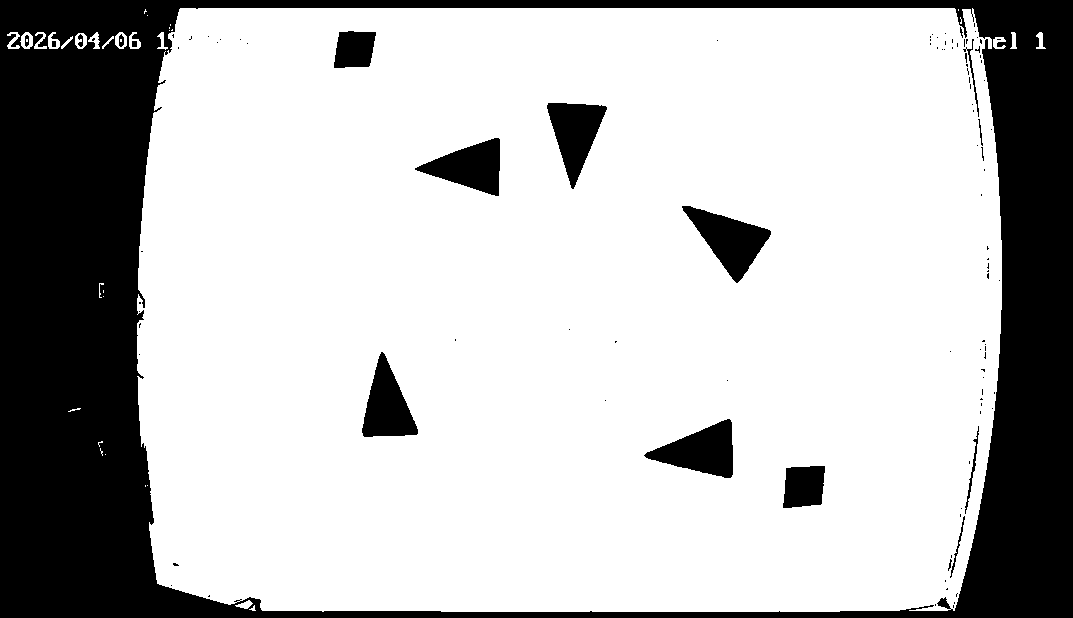

table contours: 8


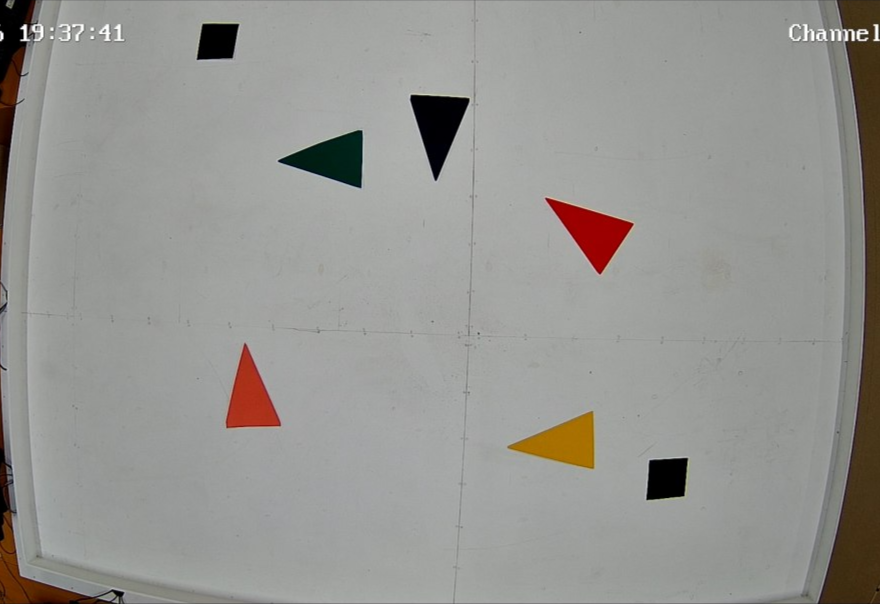

ROBOTS:
{'color': 'yellow', 'center': (0.6409090909090909, 0.7334437086092715), 'angle': np.float64(-174.98688624496418)}
{'color': 'red', 'center': (0.28295454545454546, 0.6589403973509934), 'angle': np.float64(95.1944289077348)}
{'color': 'red', 'center': (0.6738636363636363, 0.3824503311258278), 'angle': np.float64(145.49147701233161)}
{'color': 'blue', 'center': (0.49772727272727274, 0.20695364238410596), 'angle': np.float64(-92.08256527973089)}

AVERAGE:
center: (np.float64(0.5238636363636363), np.float64(0.4954470198675497))
angle: -6.595886401157163


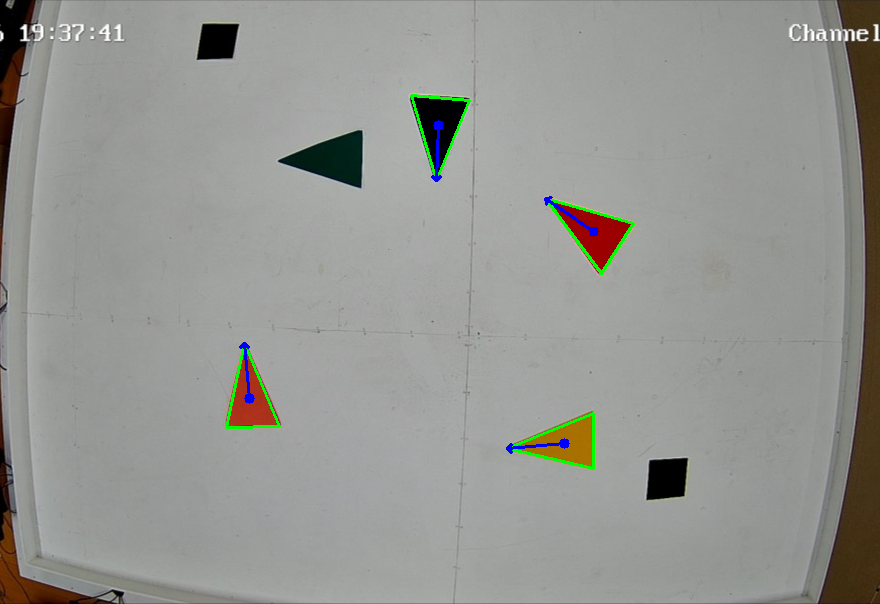

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# =====================
# Загрузка изображения
# =====================
img = cv2.imread('/content/image.png')
orig = img.copy()

# =====================
# 1. Поиск стола через HSV
# =====================
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# белый/серый = низкая насыщенность + высокая яркость
lower = np.array([0, 0, 120])
upper = np.array([180, 60, 255])

table_mask = cv2.inRange(hsv, lower, upper)

cv2_imshow(table_mask)  # <- теперь должно быть БЕЛОЕ пятно стола

# морфология
kernel = np.ones((7, 7), np.uint8)
table_mask = cv2.morphologyEx(table_mask, cv2.MORPH_CLOSE, kernel)

# контуры
contours, _ = cv2.findContours(table_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print("table contours:", len(contours))

table_contour = max(contours, key=cv2.contourArea)

x, y, w, h = cv2.boundingRect(table_contour)

table_roi = img[y:y+h, x:x+w]

cv2_imshow(table_roi)

# =====================
# 2. Поиск треугольников
# =====================
gray_roi = cv2.cvtColor(table_roi, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray_roi, (5, 5), 0)

edges = cv2.Canny(blur, 50, 150)

contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

robots = []

# HSV для цвета
hsv = cv2.cvtColor(table_roi, cv2.COLOR_BGR2HSV)

def detect_color(hsv_value):
    h, s, v = hsv_value

    if s < 50:
        return "unknown"

    if h < 10 or h > 170:
        return "red"
    elif 10 < h < 35:
        return "yellow"
    elif 35 < h < 85:
        return "green"
    elif 85 < h < 140:
        return "blue"
    else:
        return "other"

# =====================
# 3. Обработка контуров
# =====================
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 500:
        continue

    epsilon = 0.04 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)

    # ищем треугольники
    if len(approx) == 3:
        pts = approx.reshape(3, 2)

        # =====================
        # центр треугольника
        # =====================
        cx = int(np.mean(pts[:, 0]))
        cy = int(np.mean(pts[:, 1]))
        center = np.array([cx, cy])

        # =====================
        # цвет (по центру)
        # =====================
        hsv_val = hsv[cy, cx]
        color = detect_color(hsv_val)

        # =====================
        # НАПРАВЛЕНИЕ (НОВАЯ ЛОГИКА)
        # =====================
        # ищем вершину, наиболее удалённую от центра
        dists = [np.linalg.norm(p - center) for p in pts]
        tip = pts[np.argmax(dists)]

        # вектор направления
        direction_vector = tip - center

        # угол (нормальная система координат)
        angle_deg = np.degrees(
            np.arctan2(-direction_vector[1], direction_vector[0])
        )

        # =====================
        # нормализованные координаты
        # =====================
        norm_x = cx / w
        norm_y = cy / h

        robots.append({
            "color": color,
            "center": (norm_x, norm_y),
            "angle": angle_deg
        })

        # =====================
        # ВИЗУАЛИЗАЦИЯ
        # =====================
        cv2.drawContours(table_roi, [approx], -1, (0,255,0), 2)
        cv2.circle(table_roi, (cx, cy), 5, (255,0,0), -1)

        # рисуем направление (стрелка)
        end_x = int(cx + direction_vector[0])
        end_y = int(cy + direction_vector[1])

        cv2.arrowedLine(table_roi, (cx, cy), (end_x, end_y),
                        (255, 0, 0), 2)
# =====================
# 4. Средняя точка
# =====================
if robots:
    avg_x = np.mean([r["center"][0] for r in robots])
    avg_y = np.mean([r["center"][1] for r in robots])

    avg_angle = np.mean([r["angle"] for r in robots])

    print("ROBOTS:")
    for r in robots:
        print(r)

    print("\nAVERAGE:")
    print("center:", (avg_x, avg_y))
    print("angle:", avg_angle)

# =====================
# Показ результата
# =====================
cv2_imshow(table_roi)